# Multi-period (Lifecycle) model

### Goal of this lecture
- Understand the key idea behind solving multi-period (lifecycle) models: backward induction.  
  <br>
- Be able to write and implement code for the algorithm on a computer.

### Setup
- Individuals enter the economy at age 20 ($j=1$) without asset  
  <br>
- Supply one unit of labor exogenously until age 65 ($j=J_R=46$), which gives them $w$ unit of income  
  <br>
- Die at age 80 $(j=J=61)$  
  <br>
- Derive utility from consumption ($c_j$) every period and discount future by $\beta$.  
    <br>
- The asset ($a_j$) earns an interest with rate $r$. They are not allowed to borrow (i.e., $a_{j+1} \ge 0$).

The problem reads as follows:

\begin{align*}
    & \max_{\{c_j\}_{j=1}^J,\{a_{j+1}\}_{j=1}^{J-1}} \sum_{j=1}^J \beta^{j-1} u(c_j)\\
    \text{s.t.} & \\
    c_j &= 
    \begin{cases}
        w + (1+r)a_j - a_{j+1} & \text{if}~~~j\le J_R\\
        (1+r)a_j - a_{j+1} & \text{if}~~~j\in\{J_R+1,...,J-1\}\\
        (1+r)a_j & \text{if}~~~j=J\\
    \end{cases}\\
    & a_1=0, ~~a_{j+1} \ge 0~~~\forall j
\end{align*}

### Recursive formulation

Recursive formulation is useful for understanding and implementing the computational algorithm. Here, the state variables are age $j$ and current asset holdings $a$, with $a'$ representing next period's asset holdings. The value function is given as follows:

\begin{align*}
    V(a,j) = & \max_{c>0,a'\ge 0} u(c) + \beta V(a',j+1) \\
    \text{s.t.} & \\
    c &= 
    \begin{cases}
        w + (1+r)a - a' & \text{if}~~~j\le J_R\\
        (1+r)a - a' & \text{if}~~~j\in\{J_R,...,J-1\}\\
        (1+r)a & \text{if}~~~j=J\\
    \end{cases}
\end{align*}

What we want to find:  
- Value funtion $V(a,j)$  
<br>
- Policy functions for savings and consumption, $a'(a,j)$ and $c(a,j)$

### Algorithm
How do we solve the problem computationally? We solve it $\textit{backward}$.

We know that, at the end of life (i.e., age $j=J$), the value function is given as:

$$
V(a,J) = u((1+r)a) ~~~ \forall a
$$

<br>

Given the value function at the final period, the value function at age $J-1$ is given by:

$$
V(a,J-1) = \max_{a'\ge0} \left\{u((1+r)a - a') + \beta V(a',J)\right\}
$$
<br>
We can solve the optimal saving for each period by, for example, the Grid Search Method.

Once we know $V(a,J-1)$, the value function one-year behind, $V(a,J-2)$, can be solved according to:

$$
V(a,J-2) = \max_{a'\ge0} \left\{u((1+r)a - a') + \beta V(a',J-1)\right\}
$$

<br>

Continue this procedure until we obtain the value function at $j=1$:
$$
V(a,1) = \max_{a'\ge0} \left\{u((1+r)a - a') + \beta V(a',2)\right\}
$$

<br>

This procedure—solving the problem recursively from the final period backward—is known as $\textit{backward induction}$ (why not solve it $\textit{forward}$?).

### Procedure (Backward Induction with Grid Search)

- Step 1 (parametrization): Set parameters. Here, set $\beta=0.98$, $r=0.02$, $w=1.0$, $J=61$, and $J_R=46$.  
  <br>
- Step 2 (discretization): Discretize the asset space. Here, set 100 grid points over $[0, 15]$. Store it as a vector called `grida`.  
  <br>
- Step 3 (prepare value and policy functions): Prepare matrices for value and policy functions, as well as a vector to compute the utility value of each $a$.  
  <br>
- Step 4 (computing optimal choices by backward induction): Solve backward from $j=J$. For each $j$, compute the optimal $a$ based on the Grid Search. You may consider log utility.  
  <br>
- Step 5 (plot the results): Plot the age-profile for assets.


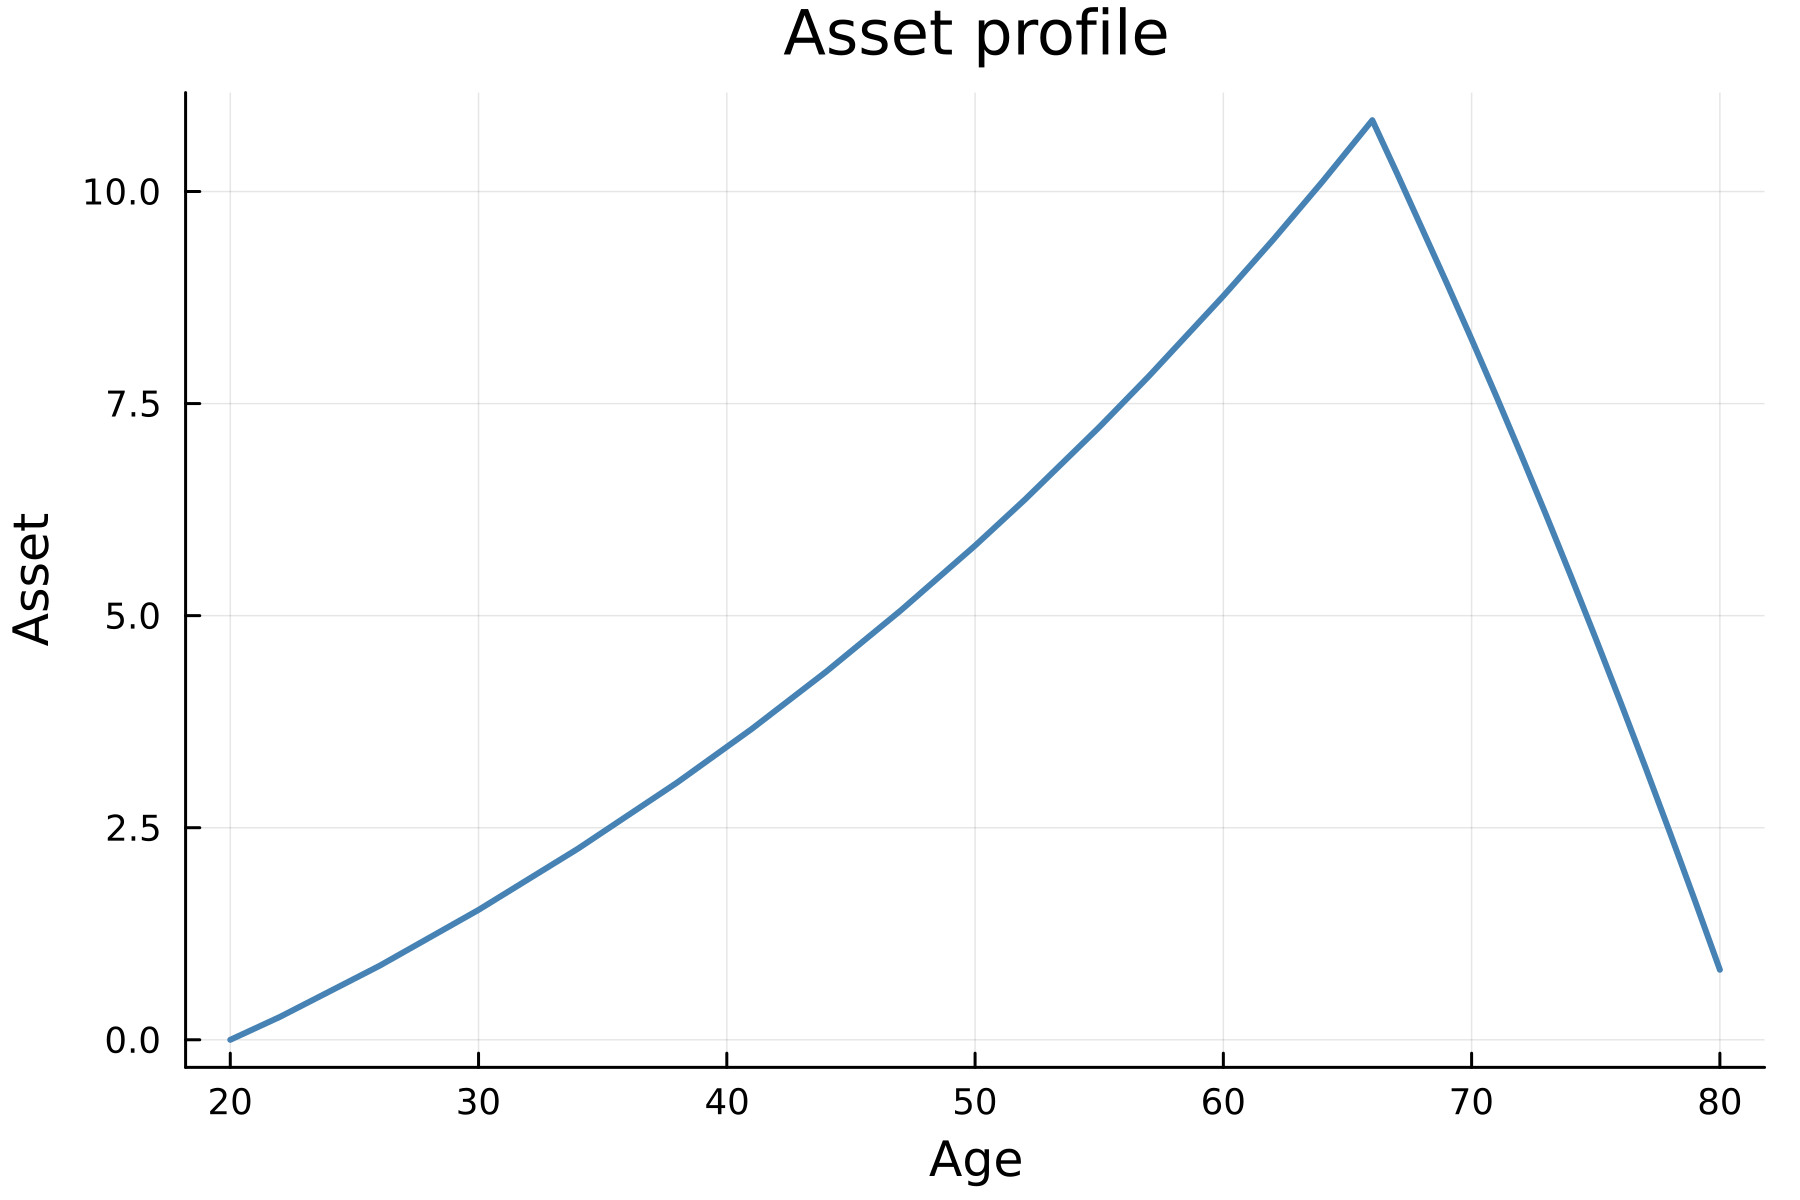

In [1]:
using Plots

# parameters
β=0.98
r=0.02
w=1.0

# discretization for asset space
mina = 1.e-5 # lower bound (close to zero but not exactly (to avoid c=0))
maxa = 15.0  # upper bound
na   = 1000  # number of grid
grida = collect(LinRange(mina,maxa,na)); # construct discretized asset space

# age related parameters
J=61  # length of lifecycle
JR=46 # timing of retirement

# value function and policy functions
V = zeros(na,J); # value function V(a,j)
Va = zeros(na);  # vector for grid search
apol = zeros(na,J); # policy function for saving (value) a(a,J)
apol_arg = ones(Int,na,J); # policy function for saving (index over asset space, grida)
cpol = zeros(na,J)  # policy function for consumption c(a,J)

penalty=-1.e+8

for jc in J:-1:1 # solve backward
    for ac in 1:na
        if (jc==J) # compute final consumption given a
            c = (1.0+r)*grida[ac]
            if (c>0)
                V[ac,jc]=log(c)
            else # "punish" c<=0
                V[ac,jc]=penalty
            end
            cpol[ac,jc]=c; # store it in policy function for c
        elseif (JR < jc) && (jc < J) # retirement period (except for the final period)
            Va.=penalty;
            for acc in 1:na
                c = (1.0+r)*grida[ac]-grida[acc]
                if (c>0)
                    Va[acc] = log(c) + β*V[acc,jc+1]
                else
                    Va[acc] = penalty
                end
            end
            arg = argmax(Va) # find optimal a' given a.
            apol_arg[ac,jc]=arg
            apol[ac,jc] = grida[arg]
            V[ac,jc] = Va[arg]
            cpol[ac,jc]=(1.0+r)*grida[ac]-grida[arg];
        else
            Va.=penalty;
            for acc in 1:na
                c = w+(1.0+r)*grida[ac]-grida[acc]
                if (c>0)
                    Va[acc] = log(c) + β*V[acc,jc+1]
                end
            end
            arg = argmax(Va)
            apol_arg[ac,jc]=arg
            apol[ac,jc] = grida[arg]
            V[ac,jc] = Va[arg]
            cpol[ac,jc]=w + (1.0+r)*grida[ac]-grida[arg];
        end
    end
end

# find asset profile aj
aj = zeros(J);
aj[1]=grida[1]; # start from no-asset
a_arg = ones(Int,J);
arg_yesterday=1;
for jc in 2:J
    arg_yesterday=a_arg[jc-1];
    arg = apol_arg[arg_yesterday,jc-1];
    aj[jc]=grida[arg];
    a_arg[jc]=arg;
end

# find consumption
cj = zeros(J);
for jc in 1:J
    arg = a_arg[jc];
    cj[jc]=cpol[arg,jc]
end

## plot asset profile
plot(20:20+J-1, aj,
    xlabel="Age",
    ylabel="Asset",
    title="Asset profile",
    lw=2,
    color = :steelblue,
    label="",
    dpi = 300)

<!-- ## Exercise
1. Construct a function that solves the model, `solve_lifecycle`, taking parameters $(r,w,\beta,J,J_r)$ and the number of grid points `na` as inputs. Return should include the age profile of asset and consumption.  
<br>
2. Using `solve_lifecycle`, solve the model and plot the results by changing only one parameter value.  e.g.,
- what if $\beta=0.96$ (or $\beta=1.0$)?
- what if $w = 0.5$?
- what if $r = 0.01$ (or $r=0.03$)?
- what if $J_R = 50$?  
<br>
Explain the economic intuition behind the differences in asset profile.  
<br>
3. The following code runs faster than the one above, given the same number of grid points na (For example, try comparing the execution time with na=1000). Think about why the version below runs faster (hint: the key factors are the use "v0" and "acc_start").  
<br>
4. Endogenous labor supply: Now consider that household labor supply is a choice. More specifically, consider that utility takes the following form: $u(c, l) = \frac{(c^{\omega} l^{1-\omega})^{1-\sigma}}{1 - \sigma}$, where $l$ denotes leisure. Before retirement (i.e., age $j\le J_R$), households choose how to allocate their time between leisure ($l$) and work ($h$) in order to earn labor income. Retired households spend all of their time on leisure. The total time endowment is normalized to 1 (i.e., $l+h\le 1$). Solve this problem and plot the labor supply profile. You may set $\sigma=2.0$ and $\omega=0.5$. -->

## Exercise
Exercise 1. Construct a function that solves the model, `solve_lifecycle`, taking parameters $(r,w,\beta,J,J_r)$ and the number of grid points `na` as inputs. Return should include the age profile of asset and consumption.  

In [17]:
function solve_lifecycle(r,w,β,J,JR,na)

    # discretization for asset space
    mina = 1.e-5 # lower bound (close to zero but not exactly (to avoid c=0))
    maxa = 15.0  # upper bound
    grida = collect(LinRange(mina,maxa,na)); # construct discretized asset space

    # value function and policy functions
    V = zeros(na,J); # value function V(a,j)
    Va = zeros(na);  # vector for grid search
    apol = zeros(na,J); # policy function for saving (value) a(a,J)
    apol_arg = ones(Int,na,J); # policy function for saving (index over asset space, grida)
    cpol = zeros(na,J)  # policy function for consumption c(a,J)

    penalty=-1.e+8

    for jc in J:-1:1 # solve backward
        for ac in 1:na
            if (jc==J) # compute final consumption given a
                c = (1.0+r)*grida[ac]
                if (c>0)
                    V[ac,jc]=log(c)
                else # "punish" c<=0
                    V[ac,jc]=penalty
                end
                cpol[ac,jc]=c; # store it in policy function for c
            elseif (JR < jc) && (jc < J) # retirement period (except for the final period)
                Va.=penalty;
                for acc in 1:na
                    c = (1.0+r)*grida[ac]-grida[acc]
                    if (c>0)
                        Va[acc] = log(c) + β*V[acc,jc+1]
                    else
                        Va[acc] = penalty
                    end
                end
                arg = argmax(Va) # find optimal a' given a.
                apol_arg[ac,jc]=arg
                apol[ac,jc] = grida[arg]
                V[ac,jc] = Va[arg]
                cpol[ac,jc]=(1.0+r)*grida[ac]-grida[arg];
            else
                Va.=penalty;
                for acc in 1:na
                    c = w+(1.0+r)*grida[ac]-grida[acc]
                    if (c>0)
                        Va[acc] = log(c) + β*V[acc,jc+1]
                    end
                end
                arg = argmax(Va)
                apol_arg[ac,jc]=arg
                apol[ac,jc] = grida[arg]
                V[ac,jc] = Va[arg]
                cpol[ac,jc]=w + (1.0+r)*grida[ac]-grida[arg];
            end
        end
    end

    # find asset profile aj
    aj = zeros(J);
    aj[1]=grida[1]; # start from no-asset
    a_arg = ones(Int,J);
    arg_yesterday=1;
    for jc in 2:J
        arg_yesterday=a_arg[jc-1];
        arg = apol_arg[arg_yesterday,jc-1];
        aj[jc]=grida[arg];
        a_arg[jc]=arg;
    end

    # find consumption
    cj = zeros(J);
    for jc in 1:J
        arg = a_arg[jc];
        cj[jc]=cpol[arg,jc]
    end

    return aj,cj
end

solve_lifecycle (generic function with 2 methods)

Exercise 1.1. Compute the asset and consumption profiles using (i) the original code and (ii) the function-based version, using the same parameter values. Compare their run times. Which version is faster?

In [18]:
# set baseline (β,r,w,J,JR,na)
β=0.98; r=0.02; w=1.0; J=61; JR=46; na=1000
@time aj, cj = solve_lifecycle(r,w,β,J,JR,na);

  0.656317 seconds (35 allocations: 1.893 MiB)


- The function-based version is much faster than the original code. Why?

- Julia specializes functions based on the types of their inputs, allowing the compiler to generate more efficient machine code.

- In contrast, the original code uses global variables, whose types are not assumed to remain fixed.

- Organizing code into functions is generally good programming practice: it makes the code more modular, easier to read and debug, and less prone to unintended changes in variables.

Exercise  2. Using `solve_lifecycle`, solve the model and plot the results by changing only one parameter value.  e.g.,
- what if $\beta=0.96$ (or $\beta=1.0$)?
- what if $w = 0.5$?
- what if $r = 0.01$ (or $r=0.03$)?
- what if $J_R = 50$?  

Why do this? Solving the model is not the end—in our own papers, we need to be able to explain in words why the model generates the quantitative results we see. Thinking through those responses also helps us catch coding or modeling errors when the results do not make economic sense.

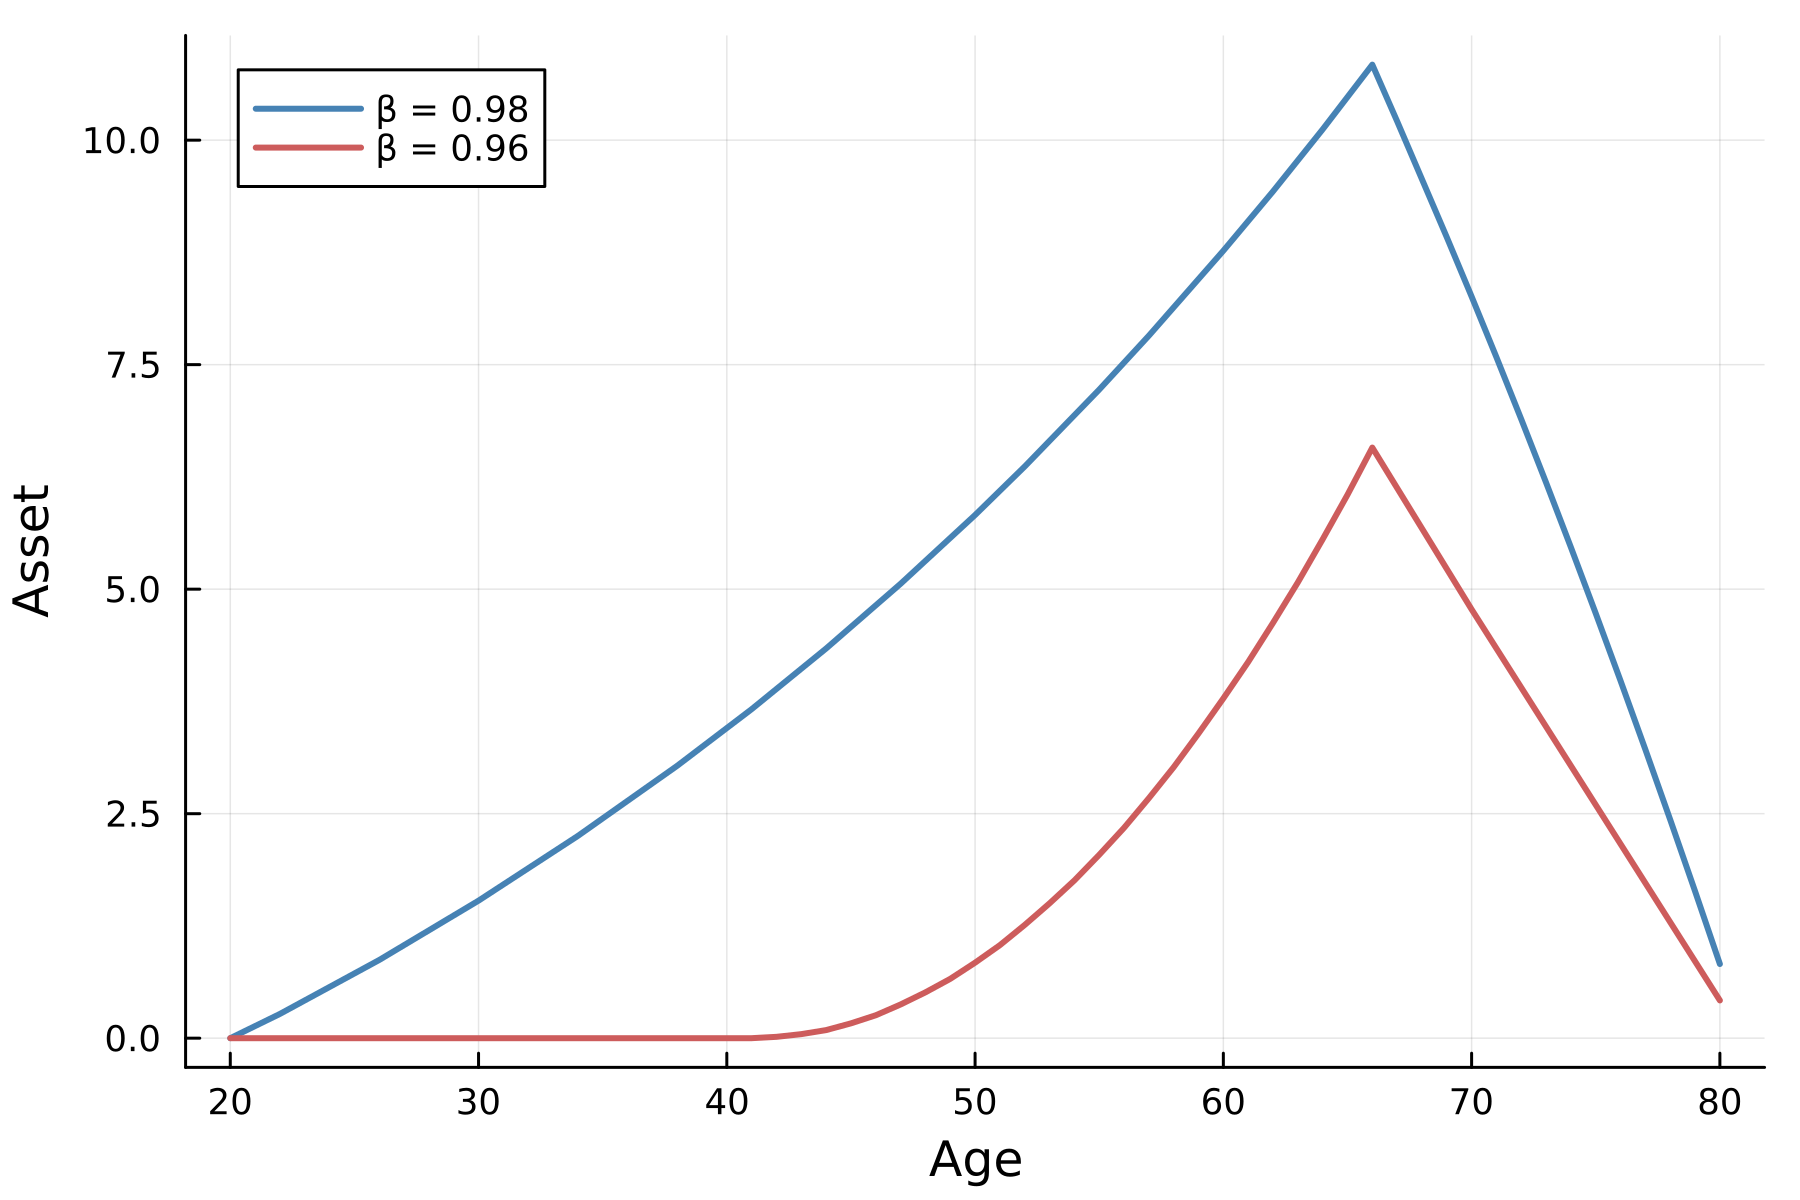

In [22]:
using Plots

# case 1: β=0.96
β_new=0.96; r=0.02; w=1.0; J=61; JR=46; na=1000
aj_new, cj_new = solve_lifecycle(r,w,β_new,J,JR,na)

# set baseline (β,r,w,J,JR,na)
β_base=0.98; r=0.02; w=1.0; J=61; JR=46; na=1000
aj_baseline, cj_baseline = solve_lifecycle(r,w,β_base,J,JR,na)

ages = 20:20+J-1 # x-axis
plot(ages, aj_baseline,
    xlabel = "Age",
    ylabel = "Asset",
    title = "",
    lw = 2,
    label = "β = $β_base",
    color = :steelblue,
    dpi = 300
)

plot!(
    ages, aj_new,
    lw = 2,
    label = "β = $β_new",
    color = :indianred
)

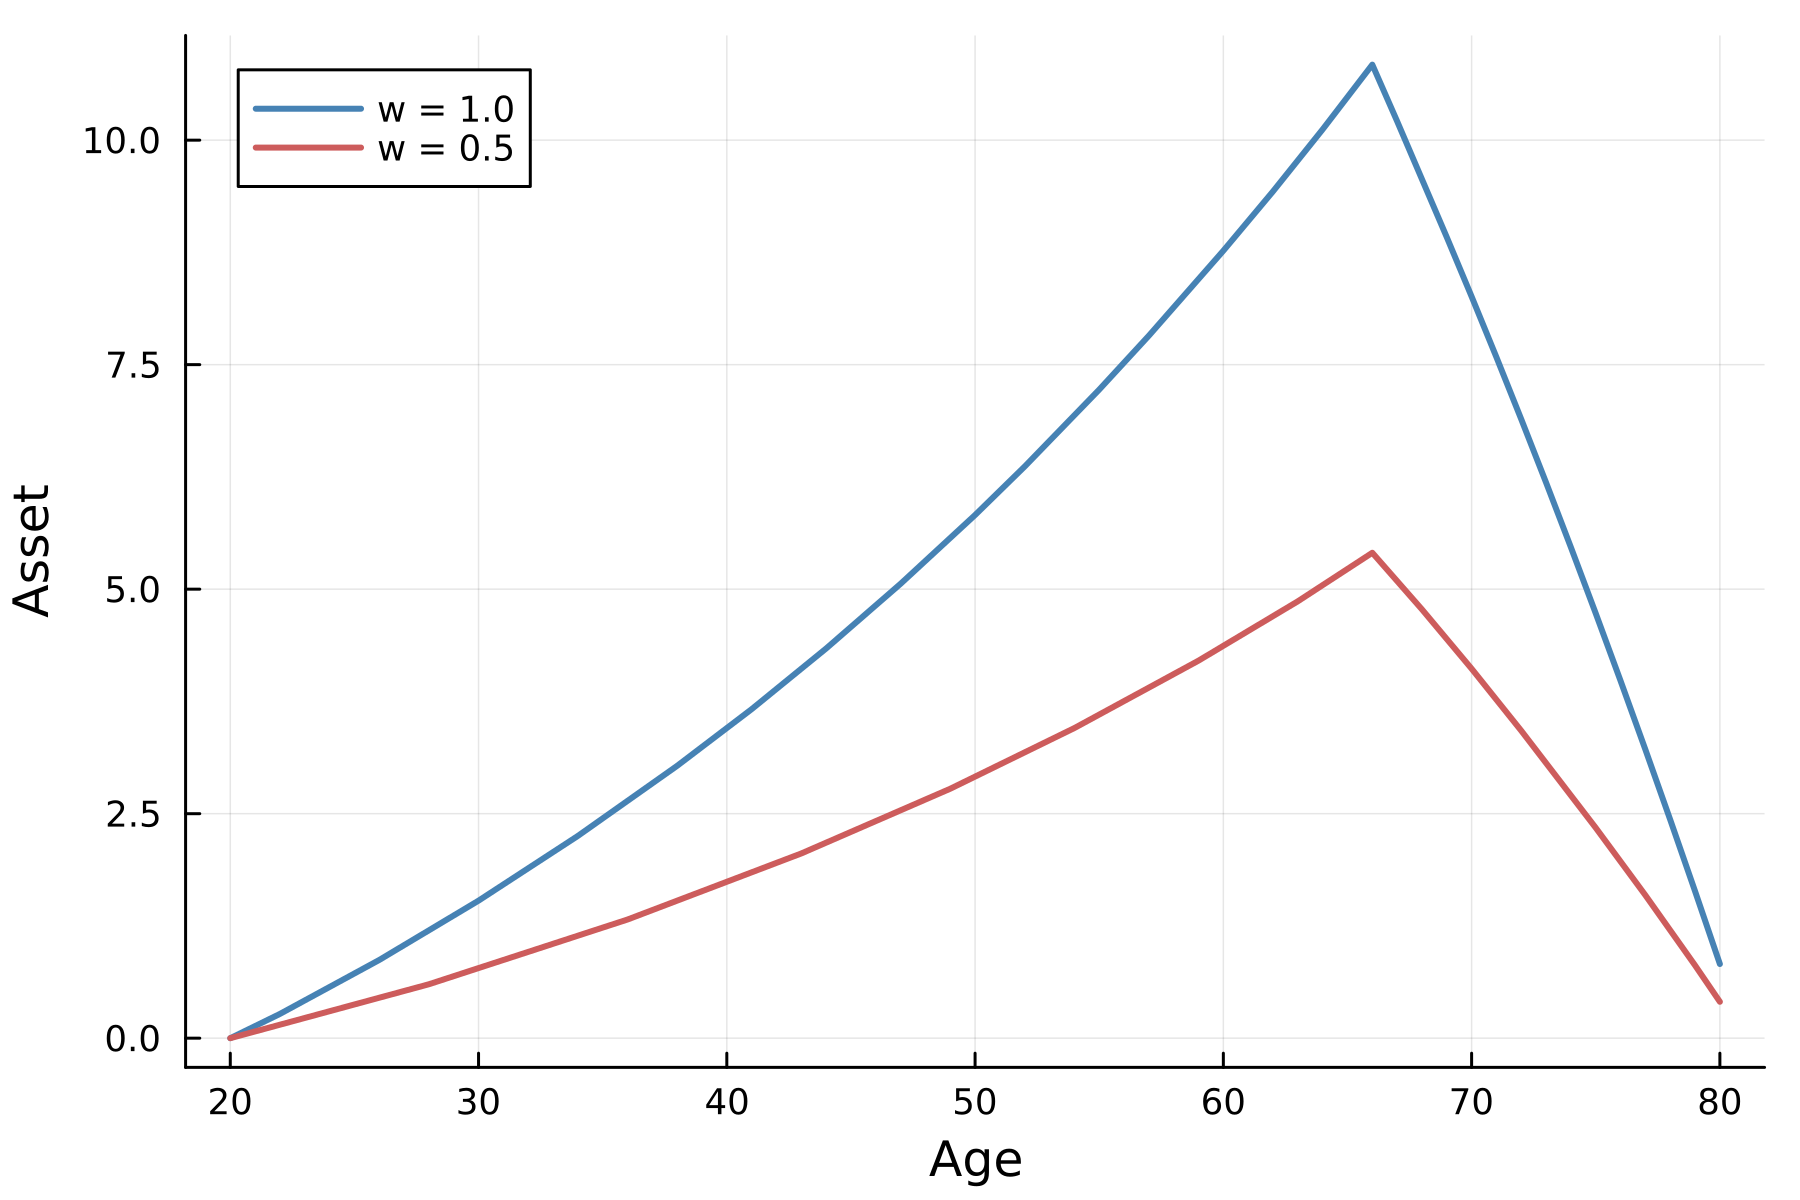

In [23]:
# case 2: w=0.5
β=0.98; r=0.02; w_new=0.5; J=61; JR=46; na=1000
aj_new, cj_new = solve_lifecycle(r,w_new,β,J,JR,na)

# set baseline (β,r,w,J,JR,na)
β=0.98; r=0.02; w_base=1.0; J=61; JR=46; na=1000
aj_baseline, cj_baseline = solve_lifecycle(r,w_base,β,J,JR,na)

ages = 20:20+J-1 # x-axis
plot(ages, aj_baseline,
xlabel = "Age",
ylabel = "Asset",
title = "",
lw = 2,
label = "w = $w_base",
color = :steelblue,
dpi = 300
)

plot!(
ages, aj_new,
lw = 2,
color = :indianred,
label = "w = $w_new"
)

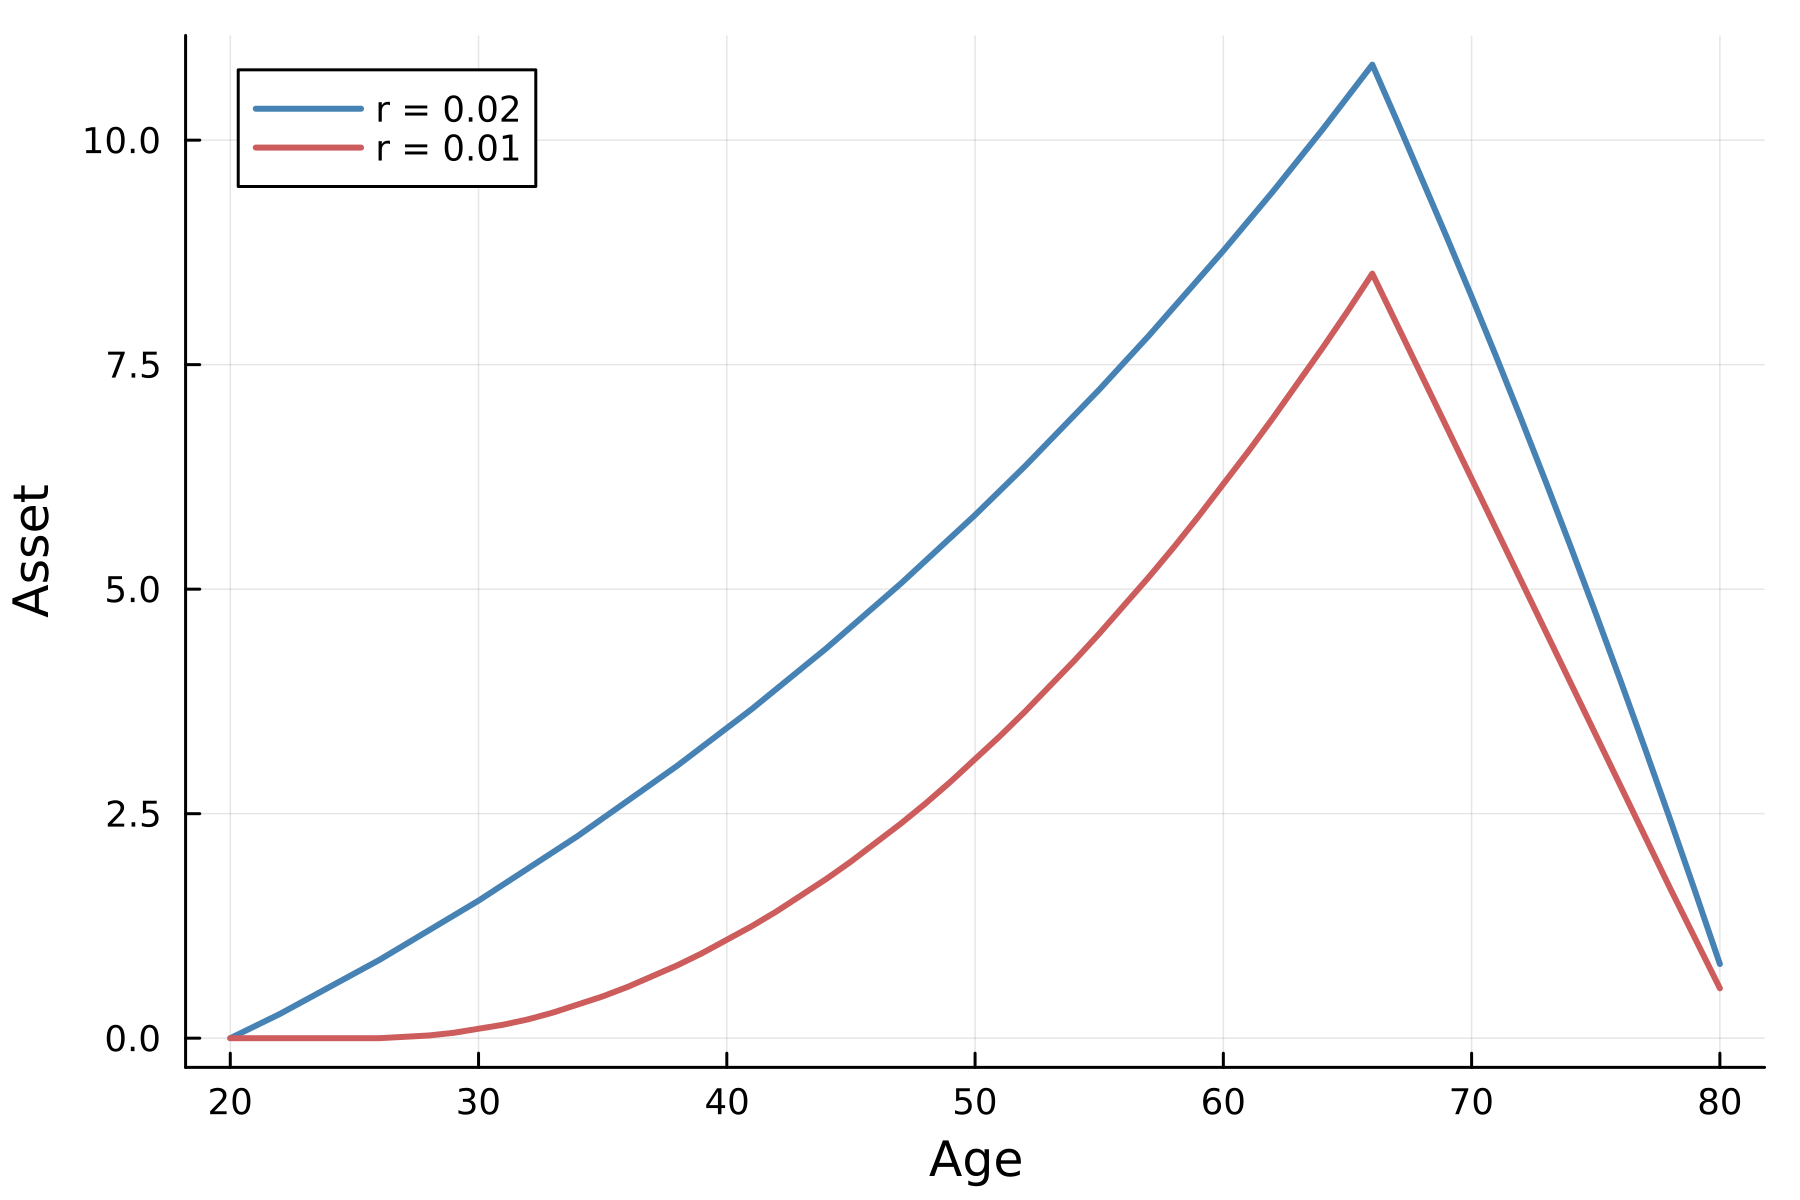

In [24]:
# case 3: r=0.01
β=0.98; r_new=0.01; w=1.0; J=61; JR=46; na=1000
aj_new, cj_new = solve_lifecycle(r_new,w,β,J,JR,na)

# set baseline (β,r,w,J,JR,na)
β=0.98; r_base=0.02; w=1.0; J=61; JR=46; na=1000
aj_baseline, cj_baseline = solve_lifecycle(r_base,w,β,J,JR,na)

ages = 20:20+J-1 # x-axis
plot(ages, aj_baseline,
xlabel = "Age",
ylabel = "Asset",
title = "",
lw = 2,
label = "r = $r_base",
color = :steelblue,
dpi = 300
)

plot!(
ages, aj_new,
lw = 2,
color = :indianred,
label = "r = $r_new"
)

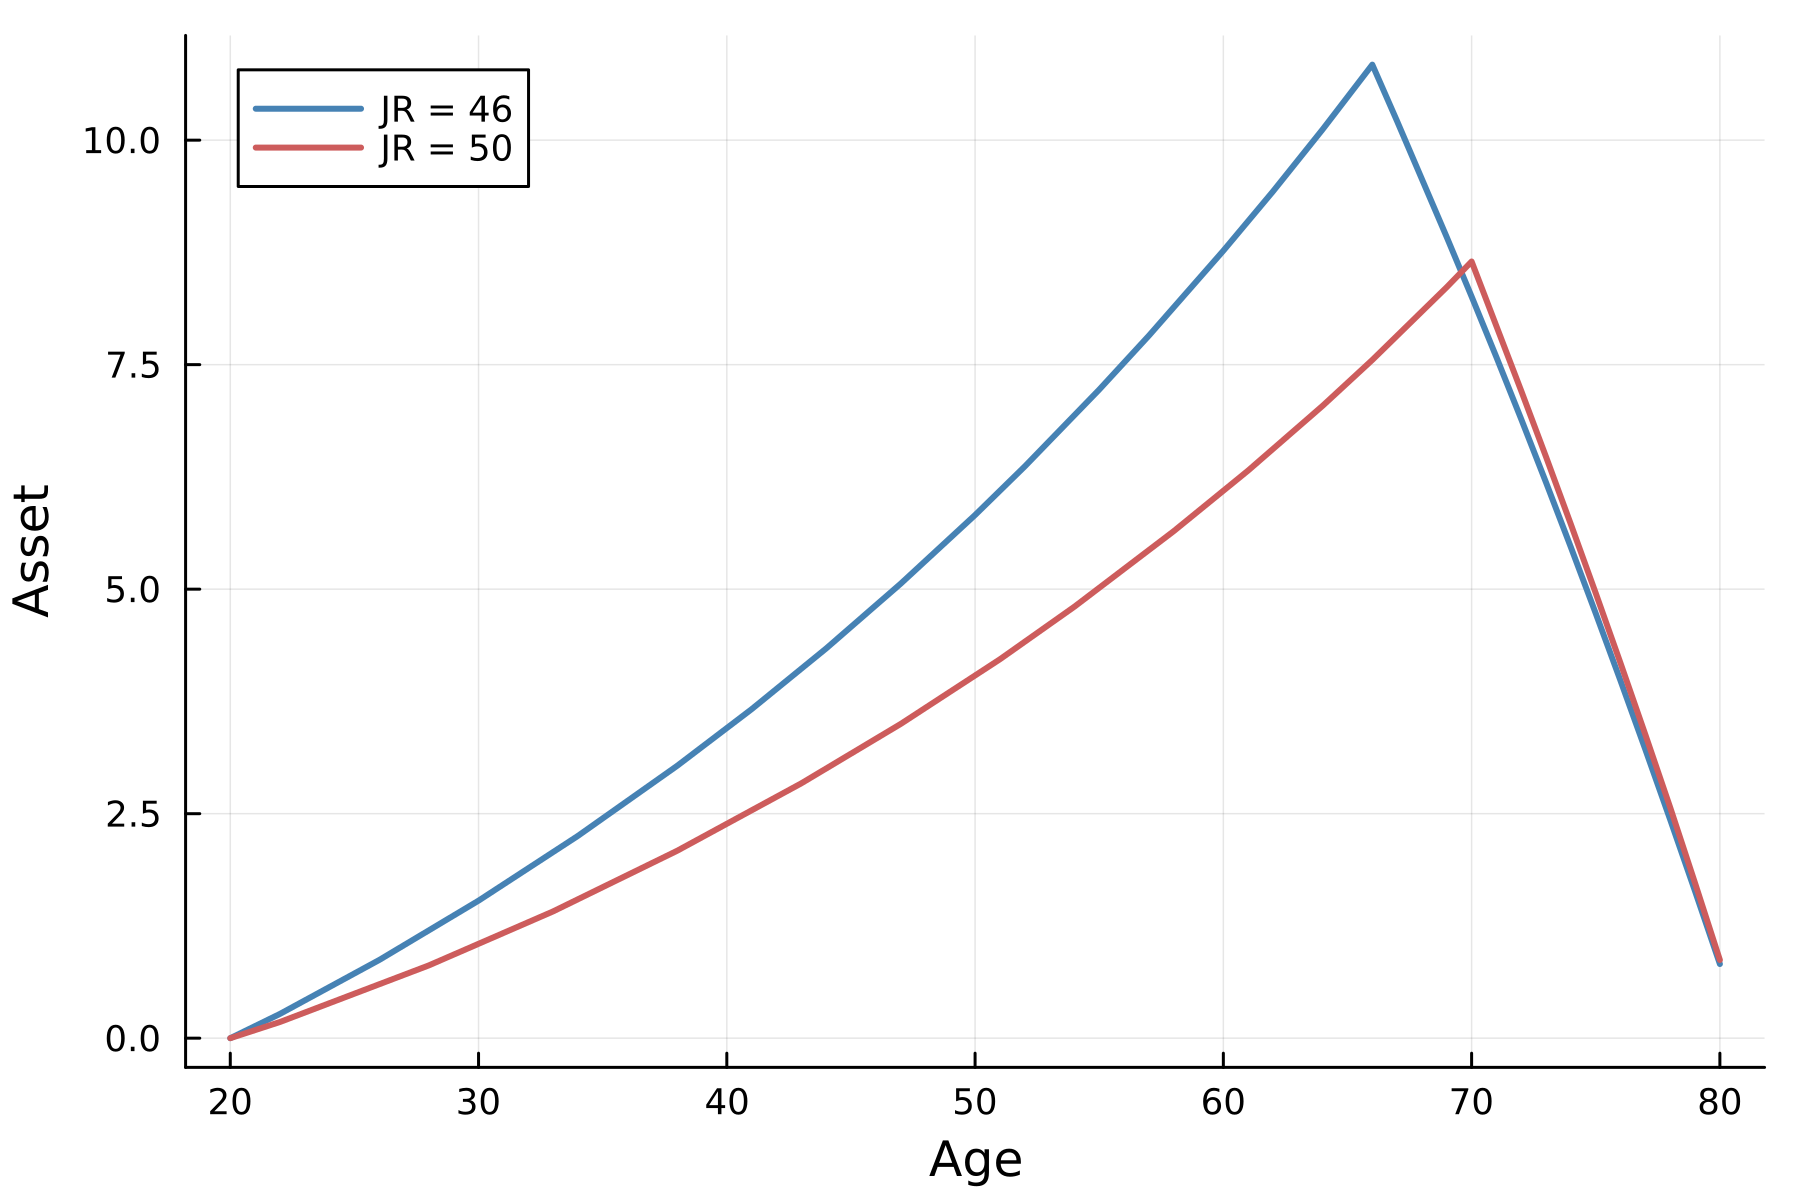

In [23]:
# case 4: JR=50
β=0.98; r=0.02; w=1.0; J=61; JR_new=50; na=1000
aj_new, cj_new = solve_lifecycle(r,w,β,J,JR_new,na)

# set baseline (β,r,w,J,JR,na)
β=0.98; r=0.02; w=1.0; J=61; JR_base=46; na=1000
aj_baseline, cj_baseline = solve_lifecycle(r,w,β,J,JR_base,na)

ages = 20:20+J-1 # x-axis
plot(ages, aj_baseline,
xlabel = "Age",
ylabel = "Asset",
title = "",
lw = 2,
label = "JR = $JR_base",
color = :steelblue,
dpi = 300
)

plot!(
ages, aj_new,
lw = 2,
color = :indianred,
label = "JR = $JR_new"
)

3. The following code runs faster than the one above, given the same number of grid points na (For example, try comparing the execution time with na=1000). Think about why the version below runs faster (hint: the key factors are the use "v0" and "acc_start"). 

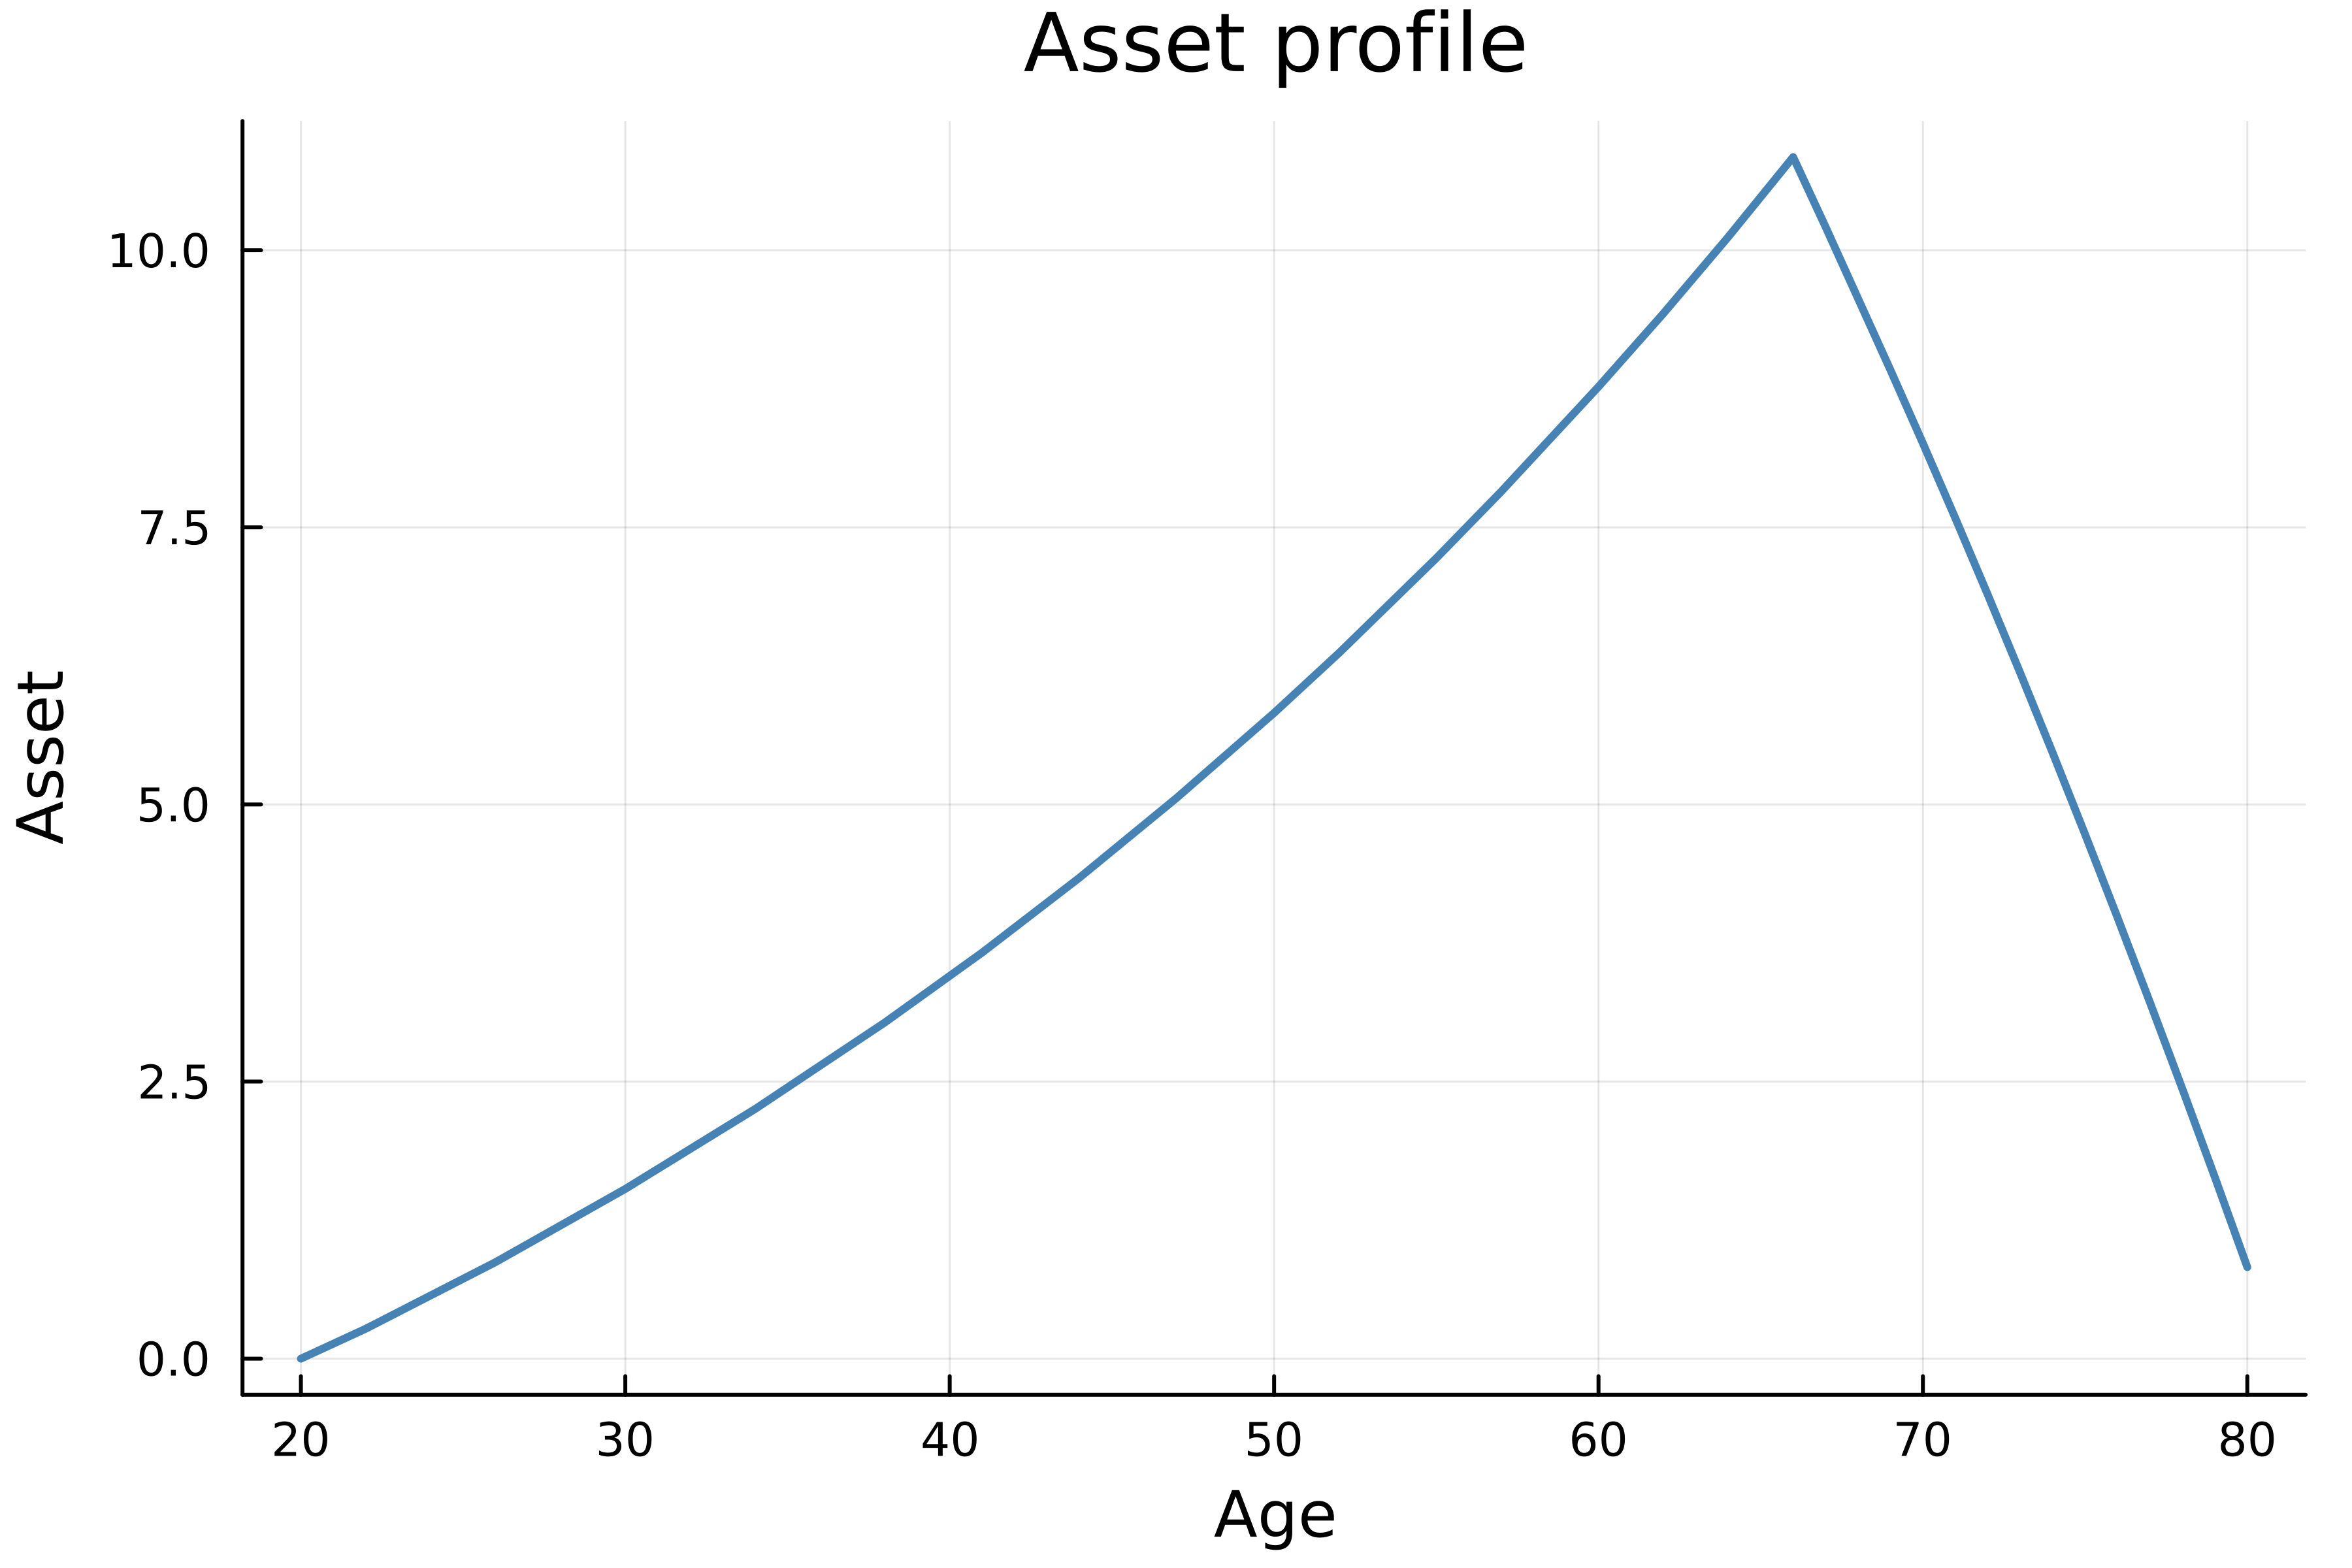

In [28]:
using Plots

# parameters
β=0.98
r=0.02
w=1.0

# discretization for asset space
mina = 1.e-5 # lower bound (close to zero but not exactly (to avoid c=0))
maxa = 15.0  # upper bound
na   = 1000  # number of grid
grida = collect(LinRange(mina,maxa,na)); # construct discretized asset space

# age related parameters
J=61  # length of lifecycle
JR=46 # timing of retirement

# value function and policy functions
V = zeros(na,J); # value function V(a,j)
Va = zeros(na);  # vector for grid search
apol = zeros(na,J); # policy function for saving (value) a(a,J)
apol_arg = zeros(Int,na,J); # policy function for saving (index over asset space, grida)
cpol = zeros(na,J)  # policy function for consumption c(a,J)

penalty=-1.e+8


for jc in J:-1:1 # solve backward
    acc_start=1 # for speed up
    for ac in 1:na
        if (jc==J) # compute final consumption given a
            c = (1.0+r)*grida[ac]
            if (c>0)
                V[ac,jc]=log(c)
            else # "punish" c<=0
                V[ac,jc]=penalty
            end
            cpol[ac,jc]=c; # store it in policy function for c
        elseif (JR < jc) && (jc < J) # retirement period (except for the final period)
            Va.=penalty;
            v0=penalty
            for acc in acc_start:na
                c = (1.0+r)*grida[ac]-grida[acc]
                if (c>0)
                    Va[acc] = log(c) + β*V[acc,jc+1]
                else
                    Va[acc] = penalty
                end

                if (Va[acc]>v0)
                    v0=Va[acc]
                    acc_start=acc
                else
                    break
                end
            end
            arg = acc_start
            apol_arg[ac,jc]=arg
            apol[ac,jc] = grida[arg]
            V[ac,jc] = Va[arg]
            cpol[ac,jc]=(1.0+r)*grida[ac]-grida[arg];
        else
            Va.=penalty;
            v0=penalty
            for acc in acc_start:na
                c = w+(1.0+r)*grida[ac]-grida[acc]
                if (c>0)
                    Va[acc] = log(c) + β*V[acc,jc+1]
                else
                    Va[acc] = penalty
                end

                if (Va[acc]>v0)
                    v0=Va[acc]
                    acc_start=acc
                else
                    break
                end

            end
            arg = acc_start
            acc_start = arg
            apol_arg[ac,jc]=arg
            apol[ac,jc] = grida[arg]
            V[ac,jc] = Va[arg]
            cpol[ac,jc]=w + (1.0+r)*grida[ac]-grida[arg];
        end
    end
end

# find asset profile aj
aj = zeros(J);
aj[1]=grida[1]; # start from no-asset
a_arg = ones(Int,J);
arg_yesterday=1;
for jc in 2:J
    arg_yesterday=a_arg[jc-1];
    arg = apol_arg[arg_yesterday,jc-1];
    aj[jc]=grida[arg];
    a_arg[jc]=arg;
end

# find consumption
cj = zeros(J);
for jc in 1:J
    arg = a_arg[jc];
    cj[jc]=cpol[arg,jc]
end

## plot asset profile
plot(20:20+J-1, aj,
    xlabel="Age",
    ylabel="Asset",
    title="Asset profile",
    lw=2,
    label="",
    color = :steelblue,
    dpi=600)

### Why?

Let's think about it one by one.

- Discretize the asset space $\mathcal{A} = \{a_1, a_2, ..., a_{N-1}, a_N\}$ with $N$ grid points and $a_1<a_2<...<a_{N-1}<a_N$.

- Let $a'(a)$ be the optimal savings rule (i.e., policy function) as a function of today's asset position $a \in \mathcal{A}$, holding other states fixed.

- Suppose that we have already computed the optimal savings for $a_i$:

$$
a'(a_i) = a_j.
$$

- We then move to the next grid point $a_{i+1}$ to obtain $a'(a_{i+1})$.

- The question is: is there anything we already know about $a'(a_{i+1})$?

- The answer is: Yes, in this problem the optimal savings policy is typically monotone. More specifically,

$$
a_{i+1} > a_i
\quad \Rightarrow \quad
a'(a_{i+1}) \geq a'(a_i).
$$

- Intuitively, when the household has more assets today, these additional resources are consumed today, while some are saved for the future.

- Recall that

$$
a'(a_i) = a_j.
$$

Then, when searching for optimal savings given $a_{i+1}$, we can ignore asset levels below $a_j$. There is no need to start the search again from $a_1$.

- This is what `acc_start` does. Instead of searching over all possible choices,

```julia
for acc in 1:na
```

the code starts from the optimal choice found for the previous asset grid point:

```julia
for acc in acc_start:na
```

- There is another source of speed improvement: `v0`.

- As we increase the choice of next-period assets $a'$, the value

$$
u(c) + \beta V(a',j+1)
$$

typically first increases, reaches its maximum, and then decreases.

- `v0` stores the highest value found so far. The code compares the value at the next grid point with `v0`:

```julia
if (Va[acc] > v0)
    v0 = Va[acc]
    acc_start = acc
else
    break
end
```

- As long as the value keeps increasing, the search continues.

- Once the value starts decreasing, the code assumes that the maximum has already been reached and exits the loop using `break`.

- Therefore, the faster code exploits two properties:

    1. `acc_start` uses the monotonicity of the policy function and avoids searching below the previous optimum.

    2. `v0` and `break` exploit the single-peaked shape of the objective and stop the search once the value starts falling.

- The naive version searches over essentially every pair $(a,a')$ (in total $N^2$ times!), while this version evaluates only a much smaller set of candidate choices. This is why the speed difference becomes substantial when the number of grid points is large, such as `na = 1000`.

Exercise 4. Endogenous labor supply: Now consider that household labor supply is a choice. More specifically, consider that utility takes the following form: $u(c, l) = \frac{(c^{\omega} l^{1-\omega})^{1-\sigma}}{1 - \sigma}$, where $l$ denotes leisure. Before retirement (i.e., age $j\le J_R$), households choose how to allocate their time between leisure ($l$) and work ($h$) in order to earn labor income. Retired households spend all of their time on leisure. The total time endowment is normalized to 1 (i.e., $l+h\le 1$). Solve this problem and plot the labor supply profile. You may set $\sigma=2.0$ and $\omega=0.5$.

Answer:

Before the retirement period, the household's budget constraint is given as:

$$
c = (1+r)a - a' + wh, 
$$
where $h$ is hours worked.

Given a pair of asset positions $(a, a')$ for today and tomorrow, we can solve for the optimal labor-leisure choice analytically:

$$
\max_{c,l} \frac{(c^\omega l^{1-\omega})^{1-\sigma}}{1-\sigma} 
$$

subject to

$$
c = (1+r)a - a' + w(1-l)
$$

First, the first-order conditions (FOCs) with respect to $c$ and $l$ imply:

$$
 \frac{c}{l} = w \cdot \frac{\omega}{1-\omega}
$$

Plugging the budget constraint into this FOC implies:

$$
l = (1-\omega)\left(1+\frac{A(a,a')}{w}\right),
$$
where $A(a,a')=(1+r)a - a'$. This optimal leisure choice determines consumption via the budget constraint and hours worked via the time constraint. We need to compute the optimal leisure and labor for each pair $(a, a')$ in the loop.

Takeaway: Try to solve the problem analytically first — in many intra-temporal optimization problems, an analytical solution is possible. An analytical solution is more accurate and (in most cases) faster than a numerical one.

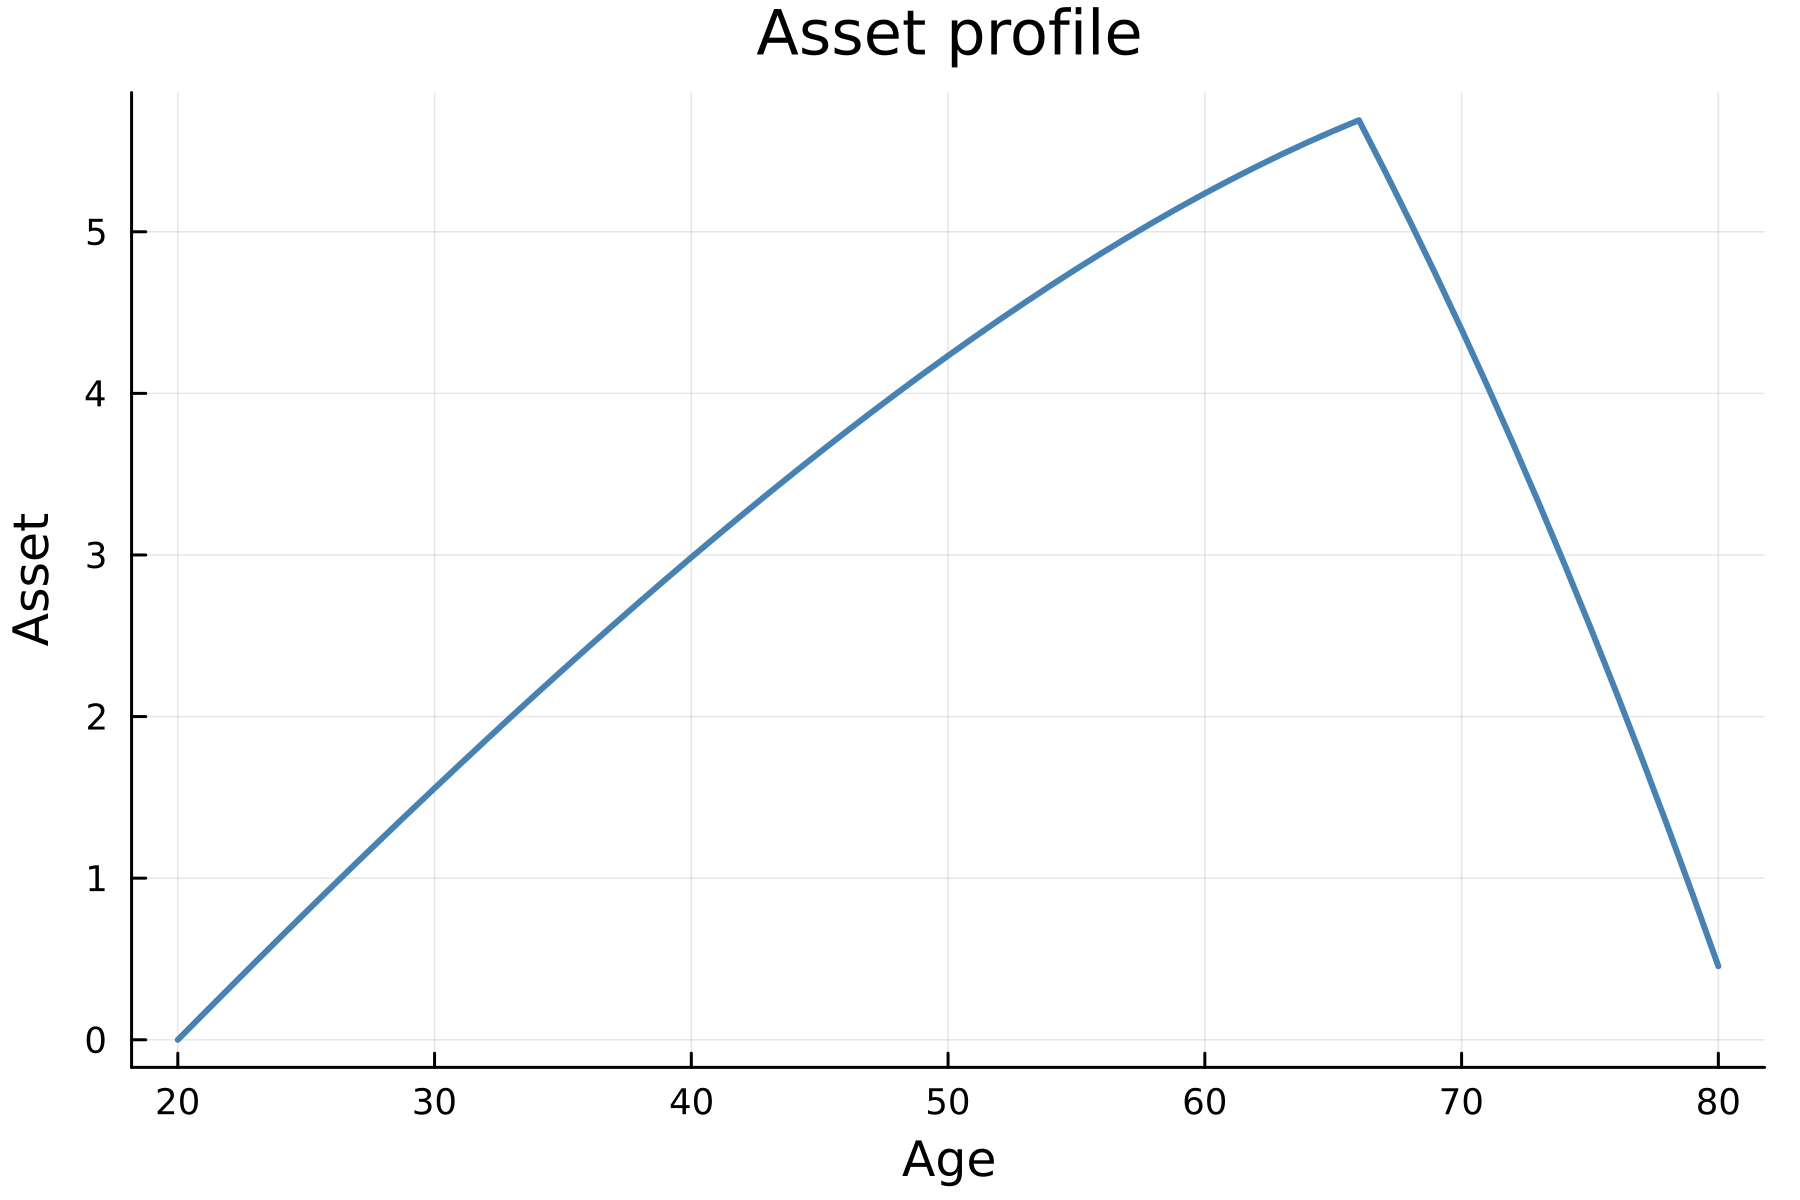

In [41]:
using Plots

# parameters
β=0.99
r=0.02
w=1.0
σ=2.0 # additional parameter (curvature)
ω=0.5 # additional parameter (weight)

# discretization for asset space
mina = 1.e-5 # lower bound (close to zero but not exactly (to avoid c=0))
maxa = 15.0  # upper bound
na   = 50000  # number of grid
grida = collect(LinRange(mina,maxa,na)); # construct discretized asset space

# age related parameters
J=61  # length of lifecycle
JR=46 # timing of retirement

# value function and policy functions
V = zeros(na,J); # value function V(a,j)
Va = zeros(na);  # vector for grid search
apol = zeros(na,J); # policy function for saving (value) a(a,J)
apol_arg = zeros(Int,na,J); # policy function for saving (index over asset space, grida)
cpol = zeros(na,J)  # policy function for consumption c(a,J)
hpol = zeros(na,J) # policy function for labor 

penalty=-1.e+8

for jc in J:-1:1 # solve backward
    acc_start=1 # for speed up
    for ac in 1:na
        if (jc==J) # compute final consumption given a
            c = (1.0+r)*grida[ac]
            if (c>0)
                V[ac,jc]=((c^ω)^(1.0-σ))/(1.0-σ)
            else # "punish" c<=0
                V[ac,jc]=penalty
            end
            cpol[ac,jc]=c; # store it in policy function for c
        elseif (JR < jc) && (jc < J) # retirement period (except for the final period)
            Va.=penalty;
            v0=penalty
            for acc in acc_start:na
                c = (1.0+r)*grida[ac]-grida[acc]
                if (c>0)
                    Va[acc] = ((c^ω)^(1.0-σ))/(1.0-σ) + β*V[acc,jc+1]
                else
                    Va[acc] = penalty
                end

                if (Va[acc]>v0)
                    v0=Va[acc]
                    acc_start=acc
                else
                    break
                end
            end
            arg = acc_start
            apol_arg[ac,jc]=arg
            apol[ac,jc] = grida[arg]
            V[ac,jc] = Va[arg]
            cpol[ac,jc]=(1.0+r)*grida[ac]-grida[arg];
        else
            Va.=penalty;
            v0=penalty
            for acc in acc_start:na
                l = (1.0-ω) * (1.0+((1.0+r)*grida[ac]-grida[acc])/w)
                c = w*(1.0-l)+(1.0+r)*grida[ac]-grida[acc]
                if (c>0 && l>0)
                    Va[acc] = ((c^ω * l^(1.0-ω))^(1.0-σ))/(1.0-σ) + β*V[acc,jc+1]
                else
                    Va[acc] = penalty
                end

                if (Va[acc]>v0)
                    v0=Va[acc]
                    acc_start=acc
                else
                    break
                end

            end
            arg = acc_start
            acc_start = arg
            apol_arg[ac,jc]=arg
            apol[ac,jc] = grida[arg]
            V[ac,jc] = Va[arg]
            l = (1.0-ω) * (1.0+((1.0+r)*grida[ac]-grida[arg])/w)
            cpol[ac,jc]=w*(1.0-l) + (1.0+r)*grida[ac]-grida[arg];
            hpol[ac,jc] = 1.0-l
        end
    end
end

# find asset profile aj
aj = zeros(J);
aj[1]=grida[1]; # start from no-asset
a_arg = ones(Int,J);
arg_yesterday=1;
for jc in 2:J
    arg_yesterday=a_arg[jc-1];
    arg = apol_arg[arg_yesterday,jc-1];
    aj[jc]=grida[arg];
    a_arg[jc]=arg;
end

# find consumption
cj = zeros(J);
hj = zeros(J)
for jc in 1:J
    arg = a_arg[jc];
    cj[jc]=cpol[arg,jc]
    hj[jc]=hpol[arg,jc]
end

## plot asset profile
plot(20:20+J-1, aj,
    xlabel="Age",
    ylabel="Asset",
    title="Asset profile",
    lw=2,
    color = :steelblue,
    label="",
    dpi=300)

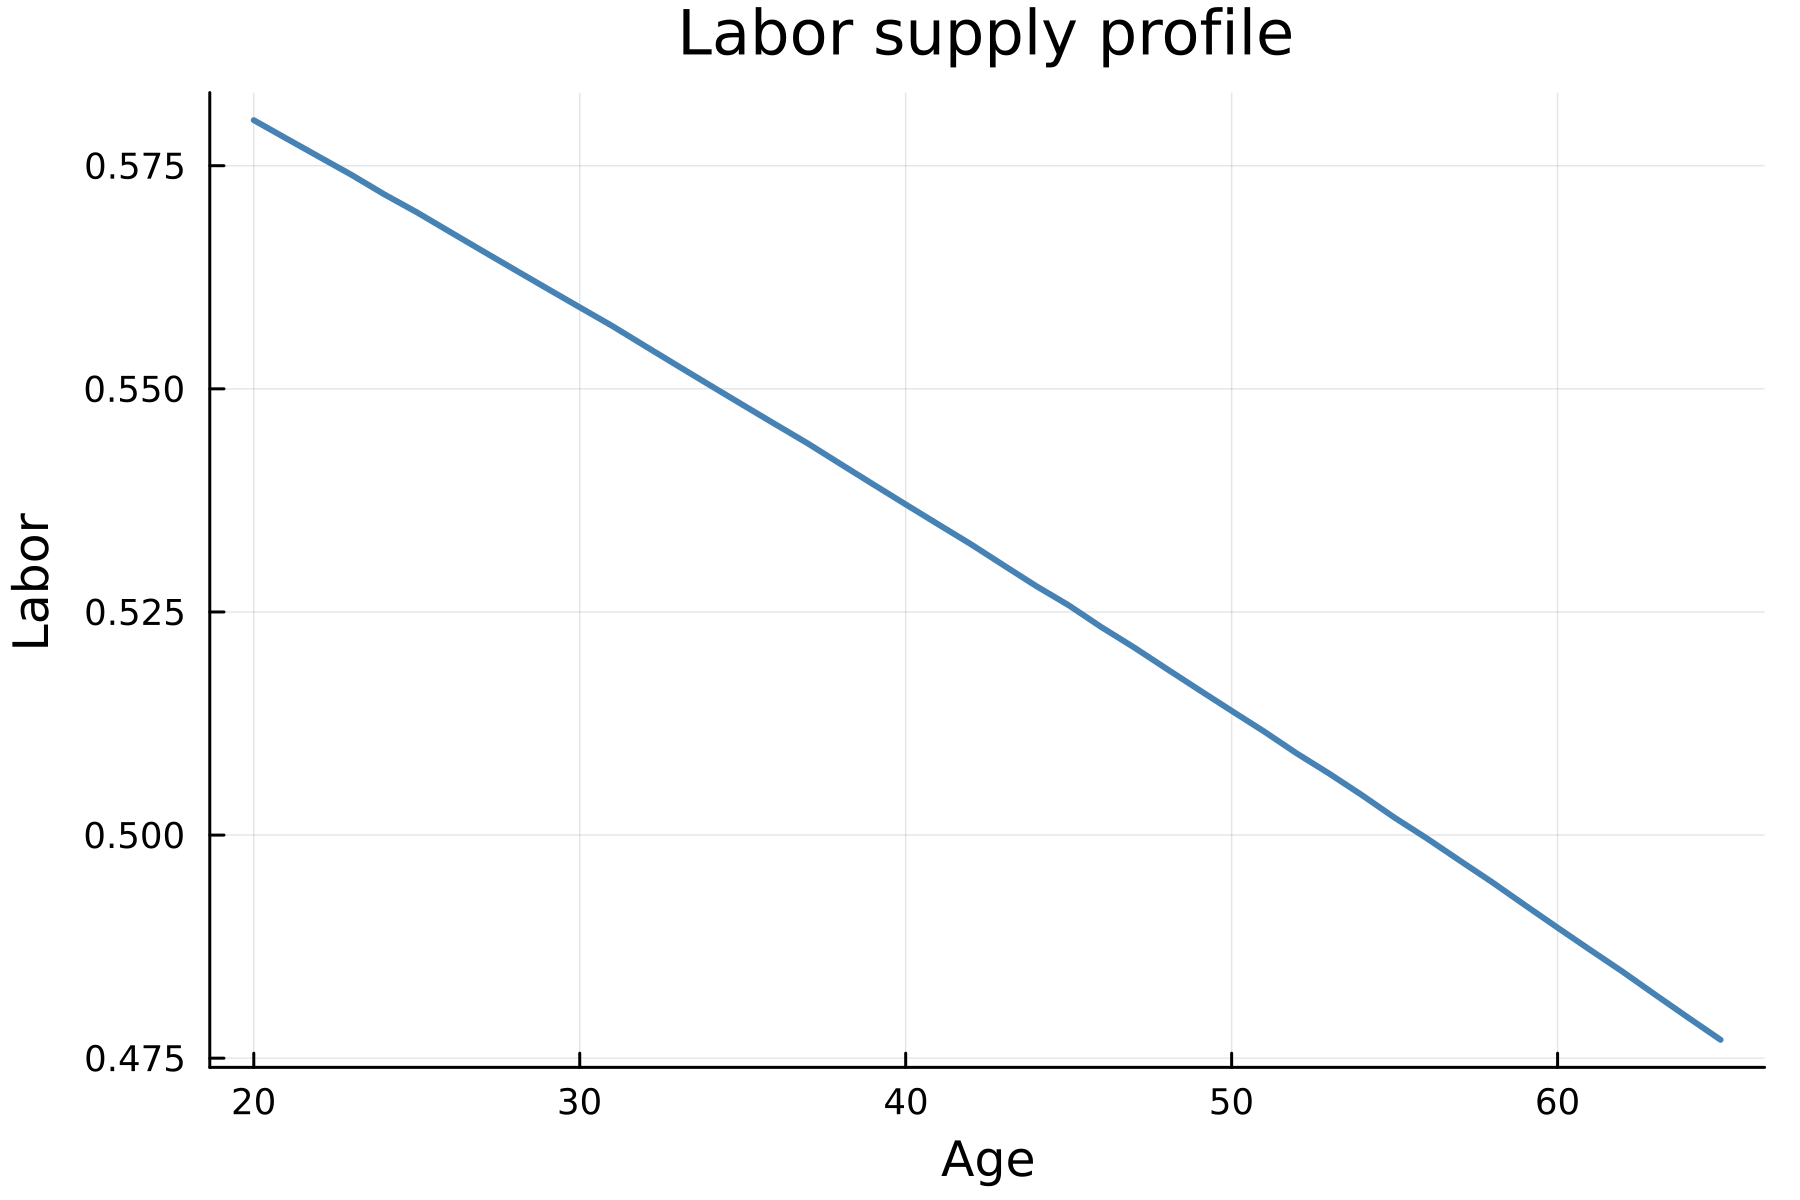

In [42]:
## plot labor supply profile
plot(20:20+JR-1, hj[1:JR],
    xlabel="Age",
    ylabel="Labor",
    title="Labor supply profile",
    lw=2,
    color = :steelblue,
    label="",
    dpi=300)